# An intro to NiSpace

In its essence, NiSpace is a Python package for correlating brain maps with each other. 

Why should we care about this, you ask?

Since many years now, methods that check for overlap between spatial characteristics of different brain maps have been in use. 
More recently, these approaches focused on spatial alignment between group- or individual-level MRI results on one side and brain maps representing potentially underlying biological levels on the other.  
Spatial correlation, or, as we will call them, *spatial colocalization* approaches, play out their key strengths when we have a hypothesis on a biological process underlying a MRI-based finding, but we cannot measure this process directly (or at least, we do not have the data at hand). 

For a straight-forward example, assume you are conducting one of these rather diabolical pain studies. In one condition, you apply electroshocks to your participants (because: why not?) and in the other condition they just lay around. You do that in an MRI scanner and run a functional scan during your task. In a simple task- design, you estimate a T-map telling you which regions activate during pain perception. You might now wonder whether these brain regions (or more specifically: the pattern of activation across regions) are related to neurotransmitter signalling supposedly involved in pain processing. Opioids and noradrenergic/cholinergic pathways come to mind. However, you cannot measure these with MRI and the ethics committee, as well as your wallet, did not allow you to do PET scans. Spatial colocalizations can give you a first hint towards your question: In the simplest case you could check whether the fMRI correlate of pain perception (i.e., your T-map) aligns with expected expression patterns of opioidergic, adrenergic, and cholinergic receptors in the healthy brain. Practically, this can be a simple correlation: If the correlation between all the region-wise values of your T-map and the expression of receptors in the same regions is strongly positive, this might be a good indication that these receptors are involved in pain processing.  
Note the lack of causality! Spatial colocalizations can give you a hint, but not a proof.

In the following, we will use NiSpace to conduct such an analysis.  
First, we will fetch a surrogate for our T-map. Then, we will check if this "T-map" *colocalizes* positively with receptor maps obtained from PET studies in healthy subjects at rest. 

## Imports

In [1]:
# load local nispace, for testing
# COMMENT THIS OUT IF YOU RUN THIS LOCALLY AFTER INSTALLING NISPACE
import sys
sys.path.append("/Users/llotter/projects/nispace/")

# import nispace workflow function
from nispace.workflows import simple_colocalization

# import imaging functions
from nilearn.image import load_img
from nilearn.plotting import view_img

## Get the T-map

I downloaded a meta-analytically derived map automatically generated from the "pain" neuroscientific literature via [NeuroQuery](https://neuroquery.org/query?text=pain+). This is not actually a T-map, but an effect size map. No difference for this example, though.

/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



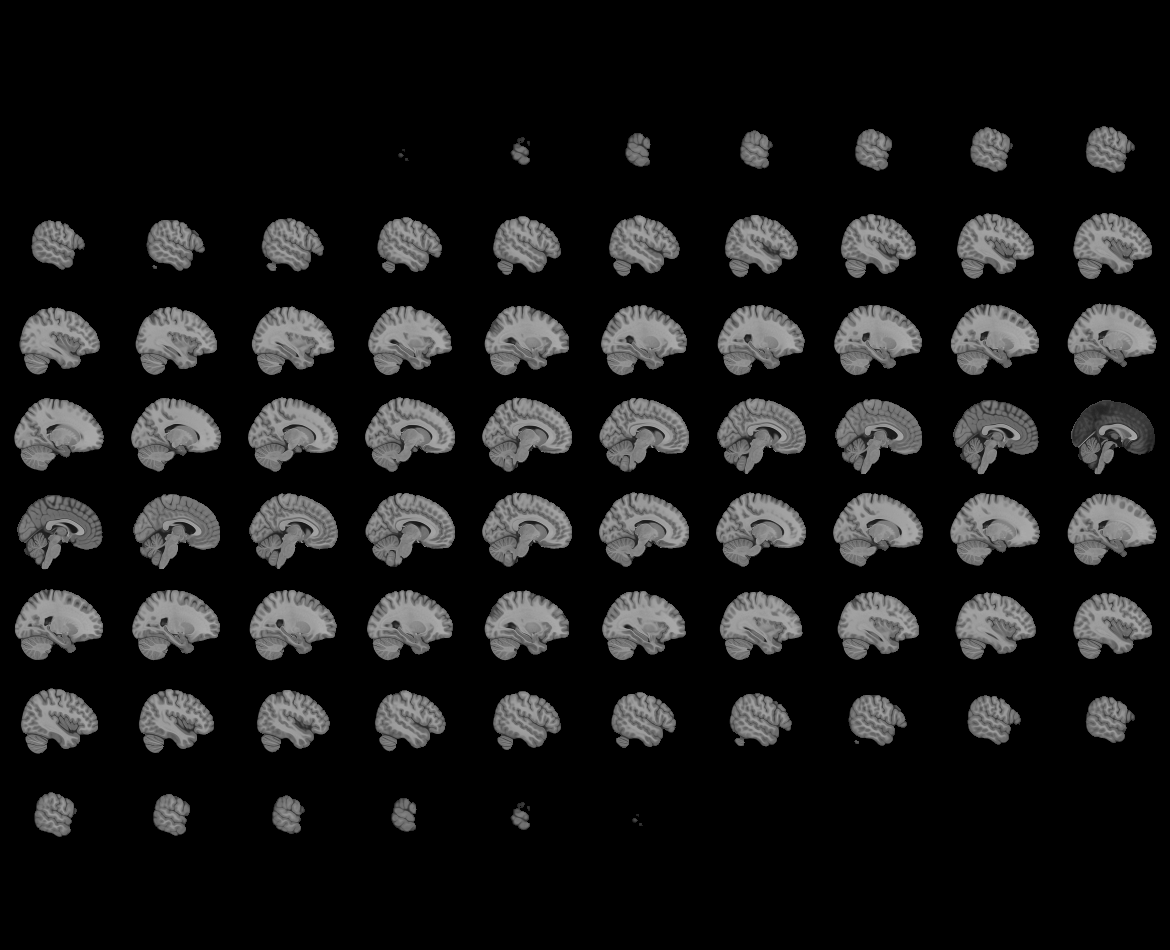
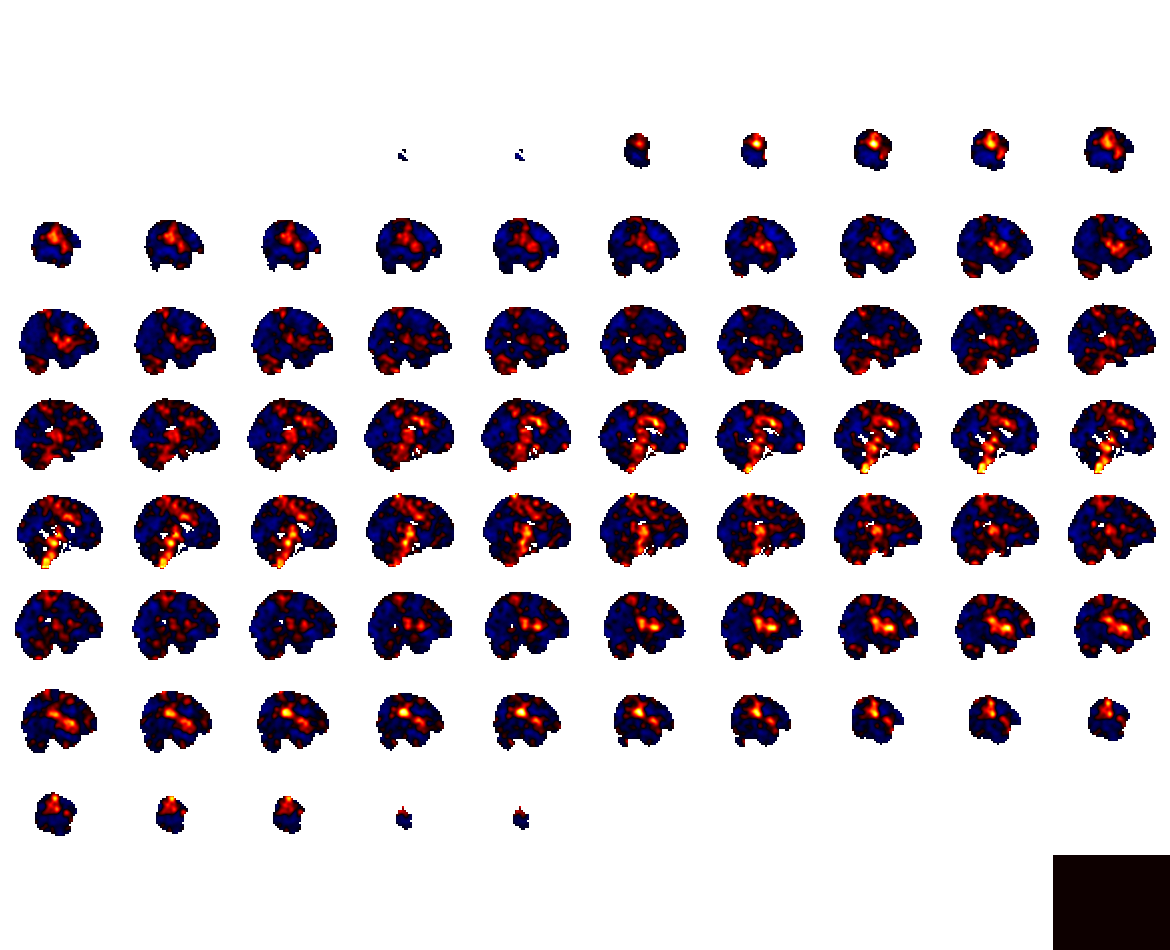

In [2]:
# the download function is a simple function to download a file from a url and save it to a temporary directory
file_path = "neuroquery/pain.nii.gz"

# load the map into memory
effect_map = load_img(file_path)

# plot the map interactively
view_img(effect_map)

## Run the analysis 

We will now run the analysis using a `workflow` function from NiSpace. Workflow functions run a complete analysis, from data loading to plotting, with a single function call.    
We will run the same analysis in individual steps in the next section. 

INFO | 09/05/25 09:02:07 | nispace: Using integrated parcellation Schaefer200MelbourneS2.
INFO | 09/05/25 09:02:07 | nispace: Loading integrated pet dataset as X data.
INFO | 09/05/25 09:02:07 | nispace: Using collection UniqueTracers.
INFO | 09/05/25 09:02:07 | nispace: Loading pet maps.
INFO | 09/05/25 09:02:07 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/pet/collection-UniqueTracers.collect.
INFO | 09/05/25 09:02:07 | nispace: Loading parcellated data: Schaefer200MelbourneS2
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152"),
the maps are downloaded directly from the source and cached locally. If, as is highly recommended, the maps are requested in 
a defined space ("MNI152NLin2009cAsym" or "MNI152NLin6Asym"), they are downloaded from the NiSpace OSF project (find them in 

Parcellating (1 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 09/05/25 09:02:08 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 09/05/25 09:02:08 | nispace: Got 'y' data for 1 x 232 parcels.
INFO | 09/05/25 09:02:08 | nispace: Z-standardizing 'X' data.
INFO | 09/05/25 09:02:08 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 09/05/25 09:02:08 | nispace: Running 'spearman' colocalization.


Colocalizing (spearman, 1 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 09/05/25 09:02:10 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 09/05/25 09:02:10 | nispace: Permutation of: X maps.
INFO | 09/05/25 09:02:10 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 09/05/25 09:02:10 | nispace: Generating permuted X maps.
INFO | 09/05/25 09:02:10 | nispace: No null maps found.
INFO | 09/05/25 09:02:10 | nispace: Generating null maps (n = 10000, null_method = 'moran').
INFO | 09/05/25 09:02:10 | nispace: Null map generation: Assuming n = 28 data vector(s) for n = 232 parcels.
INFO | 09/05/25 09:02:10 | nispace: Using provided distance matrix/matrices.
INFO | 09/05/25 09:02:10 | nispace: Generating null data separately for left and right hemisphere.


Moran null maps (1 proc):   0%|          | 0/28 [00:00<?, ?it/s]

INFO | 09/05/25 09:02:11 | nispace: Left-to-right mirroring null maps (using left-to-right mapping).


Mirroring null maps:   0%|          | 0/28 [00:00<?, ?it/s]

INFO | 09/05/25 09:02:17 | nispace: Null data generation finished.
INFO | 09/05/25 09:02:17 | nispace: Z-standardizing null maps.


Null colocalizations (spearman, 1 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 09/05/25 09:02:23 | nispace: Calculating exact p-values (tails = {'rho': 'upper'}).
INFO | 09/05/25 09:02:23 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 09/05/25 09:02:23 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 09/05/25 09:02:24 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


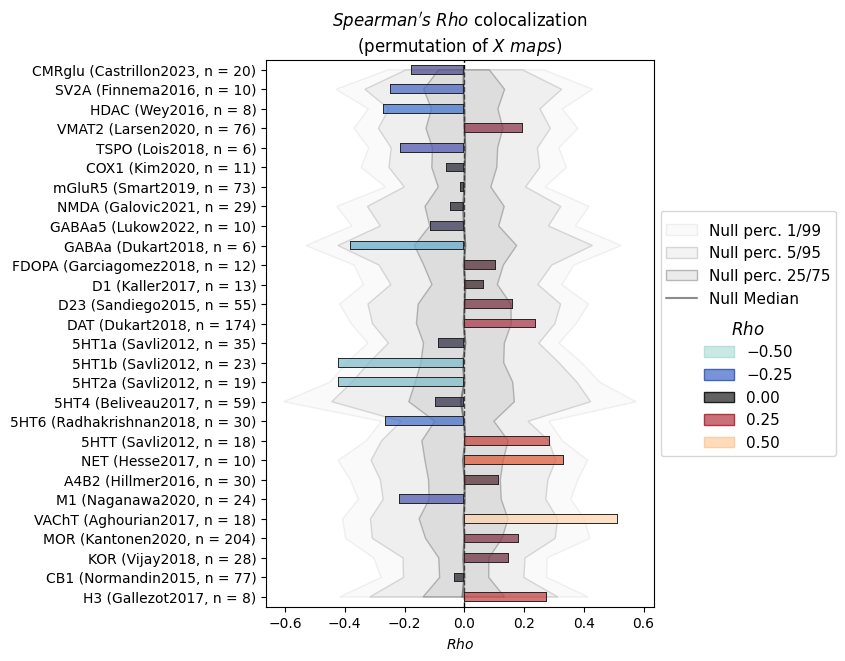

INFO | 09/05/25 09:02:25 | nispace: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
INFO | 09/05/25 09:02:25 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False | False       | False       | 
INFO | 09/05/25 09:02:25 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | fdrbh     | False | False       | False       | 


In [6]:
colocalization, p_values, p_fdr_values, nispace_object = simple_colocalization(
    y={"Pain": effect_map}, # our effect map, with the dictionary we can pass a name, can also be just the effect map
    x="pet", # the PET data, here, a pre-parcellated set of PET maps is automatically downloaded
    permute_kwargs={"p_tails": "upper"}, # This tells the function to calculate right-tailed p values according to our hypothesis
    parcellation="Schaefer200MelbourneS2", # the parcellation to use, here, Schaefer200
    seed=42, # the seed to use for the permutation analysis, for reproducibility
)

Look at that. The colorful plot in the end shows us the spatial colocalization values on the x axis (here: Z-transformed Spearman's rho). The y axis shows each PET map that went into the analysis.  
The gray shades indicate the distribution of colocalization values when the PET maps were random but contained the same level of spatial autocorrelation (i.e., a similar core spatial structure).  

As hypothesized, we observe positive colocalizations for the acetylcholine transpoter (VAChT), the K-opioid receptor (KOR), and the noradrenergic transporter (NET).  
As one can infer from the plot, the colocalizations look relatively strong, but the p values are not very low. This we see often when using group-average effect maps. An analysis of the individual maps might give us stronger effects.

The workflow function returns dataframes with colocalization values, p values, and FDR-corrected p values. Let's take a look at the p values.

In [4]:
# the p value dataframe contains one row for each input (y) map and one column for each reference (x) map
print("Output p values:")
display(p_values)

# we can display this a bit more nicely by transposing and sorting in ascending order
print("Sorted p values:")
p_values.T.sort_values(by="Pain")

Output p values:


set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
Pain                                             0.9517       

set                                                      \
map  target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016   
Pain                                             0.6862   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
Pain                                             0.9595     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
Pain                                             0.3943   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
Pain                                          0.8296   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
Pain                                         0.8159   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
Pain                                             0.2262     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
Pain                                             0.8107    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
Pain                                             0.4279       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
Pain                                             0.7908       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
Pain                                             0.8766              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
Pain                                           0.2717   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
Pain                                         0.0722   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
Pain                                             0.4435        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
Pain                                             0.7142        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
Pain                                             0.0124       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
Pain                                             0.2736           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
Pain                                             0.0809     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
Pain                                             0.3479    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
Pain                                             0.0958     

[1 rows x 28 columns]

Sorted p values:


Pain
set                         map                                                       
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...  0.0124
                            target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017      0.0722
Opiods/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vija...  0.0809
Histamine                   target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallez...  0.0958
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...  0.2262
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.2717
Opiods/Endocannabinoids     target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.2736
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.2921
Opiods/Endocannabinoids     target-CB1_tracer-omar_n-77_dx-hc_pub-normandin...  0.3479
General                     target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.3943
GABA                        target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.4279
Dopamine                    target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.4347
Serotonin                   target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.4422
Noradrenaline/Acetylcholine target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hil...  0.4435
Dopamine                    target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...  0.4700
                            target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.5262
Serotonin                   target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beli...  0.6358
General                     target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016  0.6862
Noradrenaline/Acetylcholine target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naga...  0.7142
GABA                        target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-du...  0.7908
Glutamate                   target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic...  0.8107
Immunity                    target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020      0.8159
                            target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018     0.8296
Serotonin                   target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-s...  0.8691
                            target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-rad...  0.8766
General                     target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...  0.9517
                            target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...  0.9595
Serotonin                   target-5HT1b_tracer-p943_n-23_dx-hc_pub-savli2012   0.9935

Only the VAChT p value is below 0.05, NET and KOR slightly missed the cut. As I wrote above, effects are often stronger when using individual maps.  
Nevertheless, there is an overall pattern that suggests that the pain-related activation distributes across the brain according to expected neurotransmitter pathways.

## Run the analysis in individual steps

We will now run the same analysis in individual steps. This will give us more flexibility and transparency and might help to understand what's happening. 

### Load the data

We have loaded the effect map already. Now, we load the PET maps via nispace's `fetch_reference` function.
Without additional arguments, this will download and return all PET maps contained in NiSpace's reference collection, nonlinearly aligned to defined MNI152 spaces. A long list of references will be printed automatically, like you can see in the output above. 

Here, we load a predefined set of data (`collection="UniqueTracers"`) in a specific parcellation (`parcellation="Schaefer200"`), which will return a dataframe of shape (n_maps, n_parcels). We suppress the reference list by setting `print_references=False`.

In [5]:
from nispace.datasets import fetch_reference

# fetch the PET maps
pet_maps = fetch_reference("pet", parcellation="Schaefer200", collection="UniqueTracers",
                           print_references=False)

# show the dataframe
print("PET maps dataframe. Shape:", pet_maps.shape)
pet_maps.head()

INFO | 08/05/25 12:28:49 | nispace: Loading pet maps.
INFO | 08/05/25 12:28:49 | nispace: Applying collection filter from: /Users/llotter/nispace-data/reference/pet/collection-UniqueTracers.collect.
INFO | 08/05/25 12:28:49 | nispace: Loading parcellated data: Schaefer200MelbourneS2
INFO | 08/05/25 12:28:49 | nispace: Keeping 200 cortical parcels.
INFO | 08/05/25 12:28:49 | nispace: Standardizing parcellated data.
PET maps dataframe. Shape: (28, 200)


1_LH_CX_Vis_1  \
set      map                                                                 
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...       0.108998   
         target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016       0.303389   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...       0.159557   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020       1.707210   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018         -0.674031   

                                                             2_LH_CX_Vis_2  \
set      map                                                                 
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...       0.111557   
         target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016      -0.126016   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...       0.891666   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020       0.512558   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018          0.241212   

                                                             3_LH_CX_Vis_3  \
set      map                                                                 
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...      -0.351851   
         target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016       0.015654   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...       0.179171   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020       0.005935   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018          0.920761   

                                                             4_LH_CX_Vis_4  \
set      map                                                                 
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...       0.888268   
         target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016      -0.627362   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...       1.108251   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020       0.312013   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018          1.174453   

                                                             5_LH_CX_Vis_5  \
set      map                                                                 
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...      -0.533528   
         target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016      -0.640304   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...       0.876836   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020      -0.637064   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018         -0.169330   

                                                             6_LH_CX_Vis_6  \
set      map                                                                 
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...      -1.019972   
         target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016      -1.756500   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...      -1.849139   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020       0.015052   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018         -0.523261   

                                                             7_LH_CX_Vis_7  \
set      map                                                                 
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...       0.854608   
         target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016      -0.622528   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...       1.669216   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020       0.194303   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018          0.064519   

                                                             8_LH_CX_Vis_8  \
set      map                                                                 
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...       0.376509  

### Initialize the NiSpace instance and run the data extraction

NiSpace is coded in an object-oriented way. We first initialize a NiSpace object and then run methods on it.  
Here, we initialize a NiSpace object with the effect map as dependent variable and the PET maps as independent variables.

In [6]:
from nispace.api import NiSpace

# pass the data to the NiSpace object
nsp = NiSpace(
    x=pet_maps,
    y=effect_map,
    y_labels="Pain",
    data_space="MNI152NLin6Asym",
    parcellation="Schaefer200",
)

# run the data extraction
nsp.fit()

INFO | 08/05/25 12:28:49 | nispace: *** NiSpace.fit() - Data extraction and preparation. ***
INFO | 08/05/25 12:28:49 | nispace: Loading parcellation 'Schaefer200' in 'MNI152NLin2009cAsym' space.
INFO | 08/05/25 12:28:49 | nispace: Schaefer200 is a cortex version of the whole-brain parcellation Schaefer200MelbourneS2.
INFO | 08/05/25 12:28:49 | nispace: Removing 32 subcortical parcels and returning Nifti1 object instead of path!
INFO | 08/05/25 12:28:50 | nispace: Loaded integrated parcellation with pre-calculated distance matrix.
INFO | 08/05/25 12:28:50 | nispace: Checking input data for 'x' (should be, e.g., PET data):
INFO | 08/05/25 12:28:50 | nispace: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
WARNING | 08/05/25 12:28:50 | nispace: Parcellated data contains nan values!
INFO | 08/05/25 12:28:50 | nispace: Got 'x' data for 28 x 200 parcels.
INFO | 08/05/25 12:28:50 | nispace: Checking input data for 'y' (should be, e.g., subject d

Parcellating (1 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/05/25 12:28:51 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 08/05/25 12:28:51 | nispace: Got 'y' data for 1 x 200 parcels.
INFO | 08/05/25 12:28:51 | nispace: Z-standardizing 'X' data.


With this, we performed parcellation of the input data (the effect map). The PET maps were already passed as a dataframe with regional values.

We can take a look at the parcellated input data. Again, one row per input map, one column per parcel.

In [7]:
nsp.get_y()

INFO | 08/05/25 12:28:51 | nispace: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


,1_LH_CX_Vis_1,2_LH_CX_Vis_2,3_LH_CX_Vis_3,4_LH_CX_Vis_4,5_LH_CX_Vis_5,6_LH_CX_Vis_6,7_LH_CX_Vis_7,8_LH_CX_Vis_8,9_LH_CX_Vis_9,10_LH_CX_Vis_10,...,191_RH_CX_Default_PFCm_1,192_RH_CX_Default_PFCm_2,193_RH_CX_Default_PFCm_3,194_RH_CX_Default_PFCm_4,195_RH_CX_Default_PFCm_5,196_RH_CX_Default_PFCm_6,197_RH_CX_Default_PFCm_7,198_RH_CX_Default_PCC_1,199_RH_CX_Default_PCC_2,200_RH_CX_Default_PCC_3
Pain,-0.436623,-1.075635,-0.893094,-0.887707,-1.139506,-1.259002,-1.339256,-1.083586,-1.389717,-0.828569,...,-0.463824,-0.154211,0.643321,-0.584073,-0.205924,0.174392,0.172215,-0.319737,-0.818837,-0.344202


## Run the colocalization analysis

We can now run the colocalization analysis. We will use the `colocalize` method of the NiSpace object. We use simple Spearman correlations.

In [8]:
colocalization_manual = nsp.colocalize("spearman")

INFO | 08/05/25 12:28:51 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 08/05/25 12:28:51 | nispace: Running 'spearman' colocalization.


Colocalizing (spearman, 1 proc):   0%|          | 0/1 [00:00<?, ?it/s]

We can again take a look at the results that were returned by the `colocalize` method.  
The same will be returned by `nsp.get_colocalizations()`.

In [9]:
display(colocalization_manual)

# this should be the same as the output from the workflow function
assert (colocalization_manual.values == colocalization.values).all(), "Values are not the same"

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
Pain                                          -0.209376       

set                                                      \
map  target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016   
Pain                                          -0.139078   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
Pain                                          -0.231985     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
Pain                                           0.060122   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
Pain                                       -0.204172   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
Pain                                       -0.16976   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
Pain                                           0.175147     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
Pain                                          -0.247737    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
Pain                                           0.071145       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
Pain                                          -0.293395       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
Pain                                          -0.248961              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
Pain                                          0.16964   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
Pain                                       0.317731   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
Pain                                           0.029978        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
Pain                                          -0.159238        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
Pain                                           0.470034       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
Pain                                           0.113353           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
Pain                                           0.325799     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
Pain                                           0.048895    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
Pain                                           0.298081     

[1 rows x 28 columns]

### Estimate p values via permutation analysis

We will now estimate the p values by permuting the independent variables (x, PET maps) and re-running the colocalization analysis.  
This is achieved by the `permute` method of the NiSpace object.  

In [10]:
p_values_manual = nsp.permute("maps", p_tails="upper", seed=42)

INFO | 08/05/25 12:28:51 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 08/05/25 12:28:51 | nispace: Permutation of: X maps.
INFO | 08/05/25 12:28:51 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 08/05/25 12:28:51 | nispace: Generating permuted X maps.
INFO | 08/05/25 12:28:51 | nispace: No null maps found.
INFO | 08/05/25 12:28:51 | nispace: Generating null maps (n = 10000, null_method = 'moran').
INFO | 08/05/25 12:28:51 | nispace: Null map generation: Assuming n = 28 data vector(s) for n = 200 parcels.
INFO | 08/05/25 12:28:51 | nispace: Using provided distance matrix/matrices.
INFO | 08/05/25 12:28:51 | nispace: Generating null data separately for left and right hemisphere.


Moran null maps (1 proc):   0%|          | 0/28 [00:00<?, ?it/s]

INFO | 08/05/25 12:28:52 | nispace: Left-to-right mirroring null maps (using left-to-right mapping).


Mirroring null maps:   0%|          | 0/28 [00:00<?, ?it/s]

INFO | 08/05/25 12:28:58 | nispace: Null data generation finished.
INFO | 08/05/25 12:28:58 | nispace: Z-standardizing null maps.


Null colocalizations (spearman, 1 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 08/05/25 12:29:03 | nispace: Calculating exact p-values (tails = {'rho': 'upper'}).


Again, we look at the results. You should have gotten the hang of it by now, right?

In [11]:
display(p_values_manual)

# this should be the same as the output from the workflow function
assert (p_values_manual.values == p_values.values).all(), "Values are not the same"

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
Pain                                             0.9517       

set                                                      \
map  target-SV2A_tracer-ucbj_n-10_dx-hc_pub-finnema2016   
Pain                                             0.6862   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
Pain                                             0.9595     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
Pain                                             0.3943   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
Pain                                          0.8296   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
Pain                                         0.8159   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
Pain                                             0.2262     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
Pain                                             0.8107    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
Pain                                             0.4279       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
Pain                                             0.7908       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
Pain                                             0.8766              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
Pain                                           0.2717   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
Pain                                         0.0722   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
Pain                                             0.4435        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
Pain                                             0.7142        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
Pain                                             0.0124       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
Pain                                             0.2736           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
Pain                                             0.0809     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
Pain                                             0.3479    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
Pain                                             0.0958     

[1 rows x 28 columns]

### Plot the results

There's a plot method for the NiSpace object. It tries to find the best way to visualize the results. I admit, this it not always successful in the current state, but it's a good starting point.

INFO | 08/05/25 12:29:03 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 08/05/25 12:29:04 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


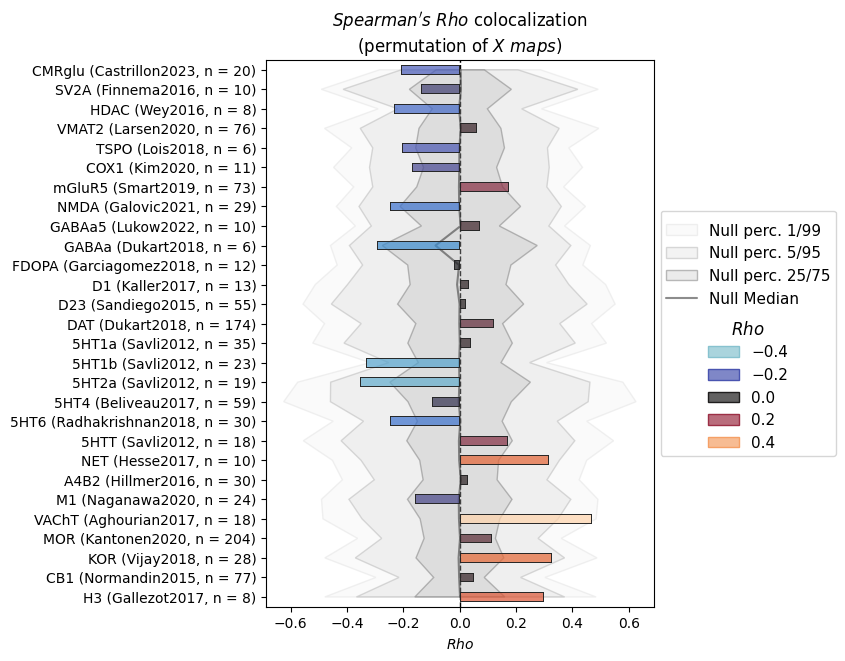

(<Figure size 500x710 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x30fe65730>)

In [12]:
nsp.plot()

## Extra: Nice correlation plot of the main result

We will create a plot of the input data projected on a brain together with the correlation between the input map and the VAChT map, which showed the strongest colocalization.

First, load the parcellated data.

In [13]:
# get the parcellated effect map
effect_map_parcellated = nsp.get_y().loc["Pain"]
display(effect_map_parcellated.head())

# get the parcellated "VAChT" PET map
k = ("Noradrenaline/Acetylcholine", "target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017")
VAChT_parcellated = nsp.get_x().loc[k]
# rename to "VAChT"
VAChT_parcellated.name = "VAChT"
display(VAChT_parcellated.head())

# plot 

INFO | 08/05/25 12:29:04 | nispace: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


1_LH_CX_Vis_1   -0.436623
2_LH_CX_Vis_2   -1.075635
3_LH_CX_Vis_3   -0.893094
4_LH_CX_Vis_4   -0.887707
5_LH_CX_Vis_5   -1.139506
Name: Pain, dtype: float32

INFO | 08/05/25 12:29:04 | nispace: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


1_LH_CX_Vis_1   -0.721861
2_LH_CX_Vis_2   -0.958405
3_LH_CX_Vis_3   -0.764613
4_LH_CX_Vis_4   -1.369476
5_LH_CX_Vis_5   -1.258625
Name: VAChT, dtype: float32

Now, create the plot. Understand the code requires some basic knowledge of plotting in Python.

Text(0.05, 0.95, 'r = 0.47, p = 0.012')

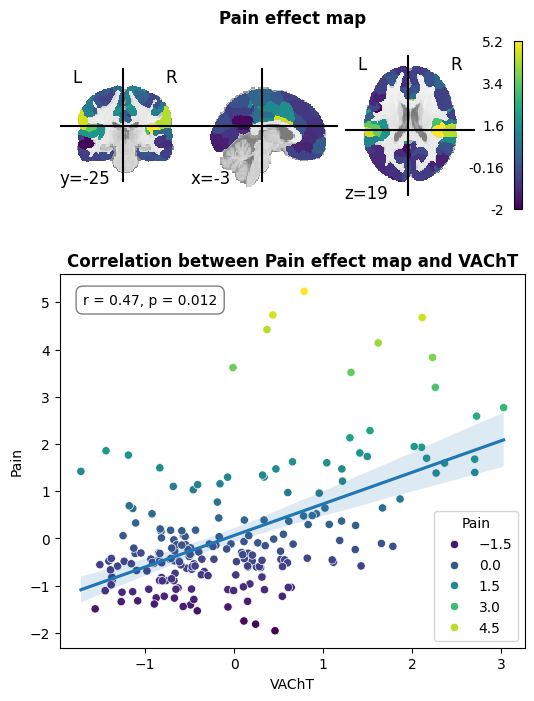

In [14]:
from seaborn import regplot,scatterplot
from matplotlib import pyplot as plt
from nilearn.plotting import plot_stat_map
from nispace.utils.utils import parc_vect_to_vol

# initialize figure
fig, (ax_brain, ax_scatter) = plt.subplots(2, 1, figsize=(6, 8), gridspec_kw={"height_ratios": [1, 2]})

# plot brains, the function parc_vect_to_vol converts the parcellated vector to a 3D image given a parcellation image
ax_brain.set_title("Pain effect map", fontweight="bold")
effect_map_parcellated_img = parc_vect_to_vol(effect_map_parcellated, nsp._parc)
plot_stat_map(
    effect_map_parcellated_img,
    cmap="viridis", symmetric_cbar=False, 
    axes=ax_brain
)

# plot scatter plot and regression line
ax_scatter.set_title("Correlation between Pain effect map and VAChT", fontweight="bold")
scatterplot(
    y=effect_map_parcellated, x=VAChT_parcellated, 
    hue=effect_map_parcellated, palette="viridis", sizes=15,
    ax=ax_scatter
)
regplot(
    y=effect_map_parcellated, x=VAChT_parcellated, 
    scatter=False, 
    ax=ax_scatter
)

# plot stats results
r = colocalization_manual.loc['Pain', k]
p = p_values_manual.loc['Pain', k]
ax_scatter.annotate(
    xy=(0.05, 0.95), xycoords="axes fraction",
    text=f"r = {r:0.2f}, p = {p:0.3f}",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.5, boxstyle="round,pad=0.5"),
)